# EZIE Mag - Weekly Notebook

**Project:** EZIE Mag Summer Research Project

This notebook is **Stage 2** of the EZIE Mag pipeline: it loads
multiple days of already-cleaned data from `data/processed/` and
produces labeled time-series plots spanning a full week.

This notebook does **no** cleaning, gap-filling, or feature
engineering of its own - all of that happens once, upstream, in the
Processing Notebook. If the days you want to look at haven't been
processed yet, run them through the Processing Notebook first.

Missing days within a week (e.g. a day with no processed file)
are skipped gracefully - the resulting plots will simply show a
gap for those days.

## 1. Setup

Import required libraries and the project's helper module.

In [13]:
# --- Path setup ---
# This notebook lives in notebooks/, but ezie_utils.py and the
# data/ folder live one level up at the project root.
import sys
import os
import datetime
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import requests

import ezie_utils

## 2. Settings

Select whether to load a standard week of data or a custom date
range, then select which device(s) to display. All selected dates
must already have been processed through the Processing Notebook
for each selected device - missing days are skipped with a warning
rather than raising an error.

In [14]:
PROCESSED_DIR = "../data/processed"

# --- Date range mode ---
range_mode = input(
    "Load a (w)eekly range or (c)ustom date range? [w/c]: "
).strip().lower()

if range_mode not in ("w", "c"):
    raise ValueError(
        f"Invalid choice '{range_mode}'. Please enter 'w' or 'c'."
    )

def _validate_date(date_str):
    """Validate that date_str is a real 8-digit YYYYMMDD date."""
    if not (date_str.isdigit() and len(date_str) == 8):
        raise ValueError(
            f"Invalid date '{date_str}'. Please enter exactly 8 "
            f"digits in YYYYMMDD format (e.g. 20260609)."
        )
    try:
        datetime.datetime.strptime(date_str, "%Y%m%d")
    except ValueError:
        raise ValueError(
            f"'{date_str}' is not a valid calendar date."
        )

if range_mode == "w":
    # --- Weekly mode ---
    # User enters the week's start date and the notebook
    # automatically generates all 7 days of that week.
    start_str = input("Enter week start date (YYYYMMDD): ").strip()
    _validate_date(start_str)

    start_date = datetime.datetime.strptime(start_str, "%Y%m%d")
    end_date = start_date + datetime.timedelta(days=6)

    DATES = []
    current = start_date
    while current <= end_date:
        DATES.append(current.strftime("%Y%m%d"))
        current += datetime.timedelta(days=1)

    print(f"Weekly range: {DATES[0]} to {DATES[-1]}")

else:
    # --- Custom range mode ---
    # User enters a start and end date and the notebook generates
    # every date in between, inclusive.
    start_str = input("Enter start date (YYYYMMDD): ").strip()
    end_str = input("Enter end date (YYYYMMDD): ").strip()
    _validate_date(start_str)
    _validate_date(end_str)

    start_date = datetime.datetime.strptime(start_str, "%Y%m%d")
    end_date = datetime.datetime.strptime(end_str, "%Y%m%d")

    if end_date < start_date:
        raise ValueError(
            f"End date {end_str} is before start date {start_str}."
        )

    DATES = []
    current = start_date
    while current <= end_date:
        DATES.append(current.strftime("%Y%m%d"))
        current += datetime.timedelta(days=1)

    print(f"Custom range: {DATES[0]} to {DATES[-1]} "
          f"({len(DATES)} days)")

# --- Device selection ---
available = ezie_utils.list_available_fingerprints(PROCESSED_DIR)

if not available:
    raise FileNotFoundError(
        f"No processed data found in {PROCESSED_DIR}. "
        f"Run the Processing Notebook first."
    )

print("\nAvailable devices:")
for fp, name in available:
    print(f"  {fp} ({name})")

device_mode = input(
    "\nLoad (s)ingle device or (m)ultiple devices? [s/m]: "
).strip().lower()

if device_mode not in ("s", "m"):
    raise ValueError(
        f"Invalid choice '{device_mode}'. Please enter 's' or 'm'."
    )

if device_mode == "s":
    fingerprint = input("Enter device fingerprint: ").strip()
    if not any(fp == fingerprint for fp, _ in available):
        raise ValueError(
            f"Fingerprint '{fingerprint}' not found in {PROCESSED_DIR}."
        )
    FINGERPRINTS = [fingerprint]

else:
    print("Enter fingerprints one at a time.")
    print("Press Enter with no input when done.")
    FINGERPRINTS = []
    while True:
        fp = input(f"  Fingerprint {len(FINGERPRINTS) + 1}: ").strip()
        if fp == "":
            if len(FINGERPRINTS) == 0:
                print("  Please enter at least one fingerprint.")
                continue
            break
        if not any(f == fp for f, _ in available):
            print(f"  Warning: '{fp}' not found in {PROCESSED_DIR} - skipping.")
            continue
        FINGERPRINTS.append(fp)

# --- Load all days for each device ---
# load_processed_days skips missing files with a warning rather
# than raising an error, so a range with a few missing days still
# loads successfully. Each device gets its own DataFrame in dfs.
dfs = {}

for fp in FINGERPRINTS:
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    df_loaded = ezie_utils.load_processed_days(DATES, fp, PROCESSED_DIR)

    if df_loaded.empty:
        print(f"Warning: no data found for {fp} ({name}) "
              f"in the requested range - skipping.")
        continue

    dfs[fp] = df_loaded
    print(f"Loaded: {fp} ({name}) - {df_loaded.shape[0]} rows "
          f"across {len(DATES)} requested days")

if not dfs:
    raise FileNotFoundError(
        "No processed data found for any selected device "
        "in the requested date range."
    )

# For single device mode, set df and fingerprint as convenience
# variables so plotting cells are consistent with the daily notebook
if len(dfs) == 1:
    df = list(dfs.values())[0]
    fingerprint = list(dfs.keys())[0]
    print(f"\nSingle device mode - df is ready.")
else:
    print(f"\nMultiple device mode - {len(dfs)} device(s) loaded.")

# Date range label for plot titles
date_label = f"{DATES[0]} to {DATES[-1]}"
print(f"Date range: {date_label}")

Load a (w)eekly range or (c)ustom date range? [w/c]:  w
Enter week start date (YYYYMMDD):  20260622


Weekly range: 20260622 to 20260628

Available devices:
  .ipynb_checkpoints (Unknown device)
  AAAAAIzs1uUA (Zane (Keller, TX))



Load (s)ingle device or (m)ultiple devices? [s/m]:  s
Enter device fingerprint:  AAAAAIzs1uUA


Loaded: AAAAAIzs1uUA (Zane (Keller, TX)) - 10080 rows across 7 requested days

Single device mode - df is ready.
Date range: 20260622 to 20260628


## 3. Load Data

Data was already loaded in the Settings section above. This cell
provides a quick sanity check - confirming the shape, time range,
and device details for each loaded DataFrame before plotting.

In [15]:
for fp, df_device in dfs.items():
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")

    print(f"\n{'='*60}")
    print(f"Device: {fp} ({name})")
    print(f"{'='*60}")
    print(f"Shape:      {df_device.shape}")
    print(f"Time range: {df_device.index.min()} to "
          f"{df_device.index.max()}")

    # Count how many days actually loaded vs how many were requested
    # A day that was missing from data/processed/ will simply not
    # appear in the index rather than showing as NaN rows, since
    # load_processed_days skips missing files entirely.
    days_loaded = df_device.index.normalize().nunique()
    print(f"Days loaded: {days_loaded} / {len(DATES)} requested")

    if days_loaded < len(DATES):
        # Identify which requested dates are missing
        loaded_dates = set(
            df_device.index.normalize()
            .strftime("%Y%m%d")
            .unique()
        )
        missing_dates = [d for d in DATES if d not in loaded_dates]
        print(f"Missing dates: {missing_dates}")

    # Quick flag summary across all loaded days
    flag_cols = [c for c in df_device.columns if c.startswith("flag_")]
    flagged = {
        c: int(df_device[c].sum())
        for c in flag_cols
        if df_device[c].sum() > 0
    }

    if flagged:
        print("\nFlags raised across all loaded days:")
        for flag, count in flagged.items():
            print(f"  {flag}: {count} row(s)")
    else:
        print("\nFlags raised: none")

    display(df_device.head())


Device: AAAAAIzs1uUA (Zane (Keller, TX))
Shape:      (10080, 37)
Time range: 2026-06-22 00:00:00+00:00 to 2026-06-28 23:59:00+00:00
Days loaded: 7 / 7 requested

Flags raised across all loaded days:
  flag_outlier_bx: 90 row(s)
  flag_outlier_bz: 41 row(s)
  flag_outlier_bh: 57 row(s)
  flag_low_nsamp: 97 row(s)
  flag_sensor_disturbed: 192 row(s)
  flag_missing: 5 row(s)


,tval,intt,nsamp,stid,fingerprint,lat,lon,alt,tres,ctemp,...,flag_outlier_by,flag_outlier_bz,flag_outlier_bh,flag_outlier_ctemp,flag_outlier_imu_ctemp,flag_low_nsamp,flag_gps,flag_sensor_disturbed,flag_config_change,flag_missing
timeString,,,,,,,,,,,,,,,,,,,,,
2026-06-22 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,True
2026-06-22 00:01:00+00:00,1.782086e+09,60.0,1997.0,"""eziemag""",AAAAAIzs1uUA,32.952093,-97.255788,226.4,3.0,23.8125,...,False,False,False,False,False,False,False,False,False,False
2026-06-22 00:02:00+00:00,1.782087e+09,60.0,2032.0,"""eziemag""",AAAAAIzs1uUA,32.952093,-97.255788,226.4,3.0,23.8750,...,False,False,False,False,False,False,False,False,False,False
2026-06-22 00:03:00+00:00,1.782087e+09,60.0,2031.0,"""eziemag""",AAAAAIzs1uUA,32.952093,-97.255788,226.4,3.0,23.8125,...,False,False,False,False,False,False,False,False,False,False
2026-06-22 00:04:00+00:00,1.782087e+09,60.0,2017.0,"""eziemag""",AAAAAIzs1uUA,32.952093,-97.255788,226.4,3.0,23.8125,...,False,False,False,False,False,False,False,False,False,False


## 4. Multi-Day Plots: Bx, By, Bz

Time-series plots of the three raw magnetic field components across
the full date range. The x-axis uses real UTC timestamps so any
missing days or data gaps appear naturally as breaks in the line
rather than misleading straight-line connections. In multi-device
mode, each device is plotted on the same axes for direct comparison.

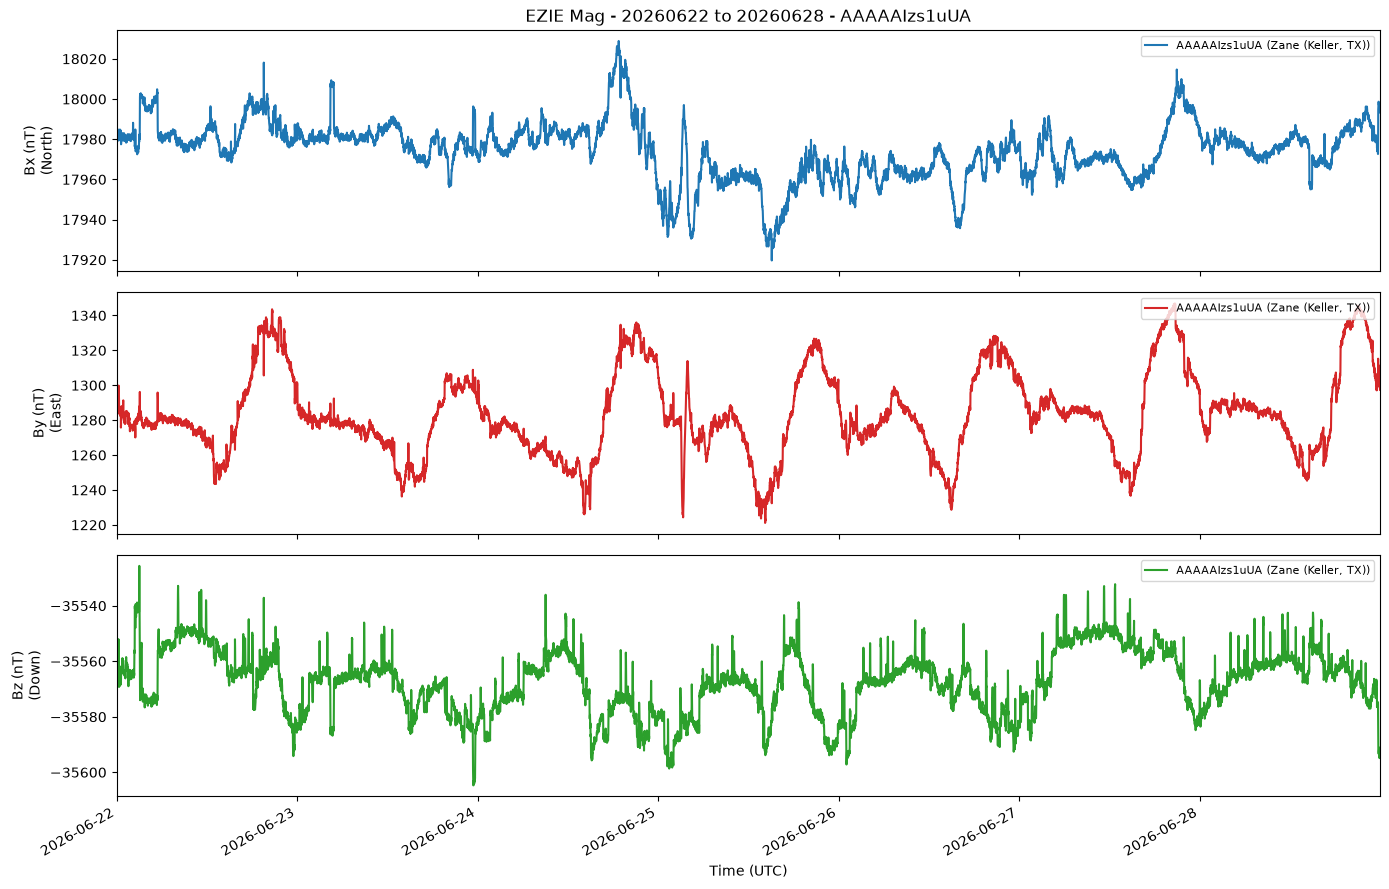

In [16]:
line_styles = ["-", "--", ":", "-."]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for i, (fp, df_device) in enumerate(dfs.items()):
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    label = f"{fp} ({name})"
    ls = line_styles[i % len(line_styles)]

    axes[0].plot(df_device.index, df_device["Bx"],
                 color="tab:blue", linestyle=ls, label=label)
    axes[1].plot(df_device.index, df_device["By"],
                 color="tab:red", linestyle=ls, label=label)
    axes[2].plot(df_device.index, df_device["Bz"],
                 color="tab:green", linestyle=ls, label=label)

axes[0].set_ylabel("Bx (nT)\n(North)")
axes[1].set_ylabel("By (nT)\n(East)")
axes[2].set_ylabel("Bz (nT)\n(Down)")
axes[2].set_xlabel("Time (UTC)")

fp_str = " | ".join(FINGERPRINTS)
axes[0].set_title(f"EZIE Mag - {date_label} - {fp_str}")

first_df = list(dfs.values())[0]
for ax in axes:
    ax.set_xlim(first_df.index.min(), first_df.index.max())
    ax.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Total Field Magnitude (B_total)

$$B_{total} = \sqrt{B_x^2 + B_y^2 + B_z^2}$$

Rotation-independent overall field strength across the full date
range, comparable to an observatory's reported F value. In
multi-device mode, each device is plotted on the same axes for
direct comparison.

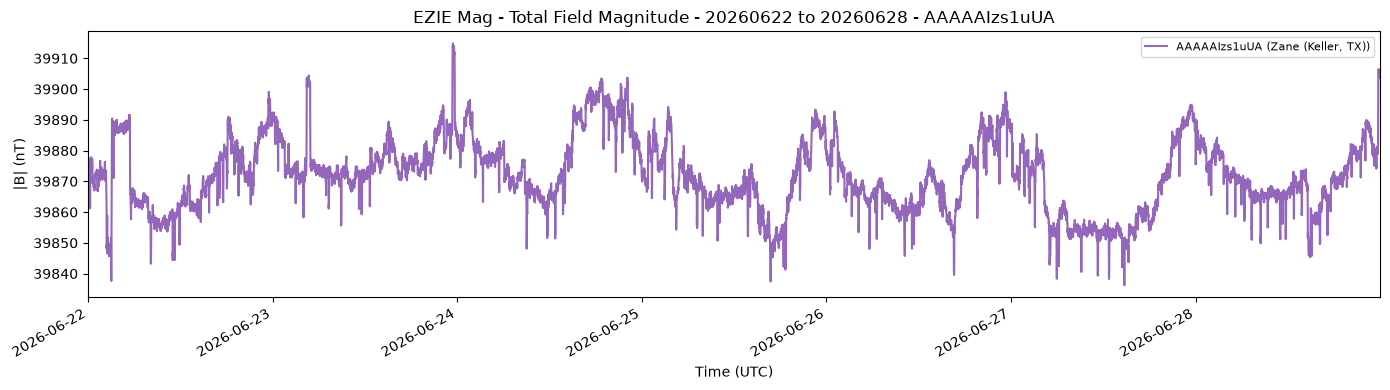

In [17]:
line_styles = ["-", "--", ":", "-."]

fig, ax = plt.subplots(figsize=(14, 4))

for i, (fp, df_device) in enumerate(dfs.items()):
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    label = f"{fp} ({name})"
    ls = line_styles[i % len(line_styles)]

    ax.plot(df_device.index, df_device["B_total"],
            color="tab:purple", linestyle=ls, label=label)

ax.set_ylabel("|B| (nT)")
ax.set_xlabel("Time (UTC)")

fp_str = " | ".join(FINGERPRINTS)
ax.set_title(
    f"EZIE Mag - Total Field Magnitude - {date_label} - {fp_str}"
)

first_df = list(dfs.values())[0]
ax.set_xlim(first_df.index.min(), first_df.index.max())
ax.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6. Horizontal Field Magnitude (Bh)

$$B_h = \sqrt{B_x^2 + B_y^2}$$

Combines the North and East components only, excluding the vertical
Down component, across the full date range. This is the primary
scientific comparison metric since Bz can differ significantly
between stations due to local conditions. In multi-device mode,
each device is plotted on the same axes for direct comparison.

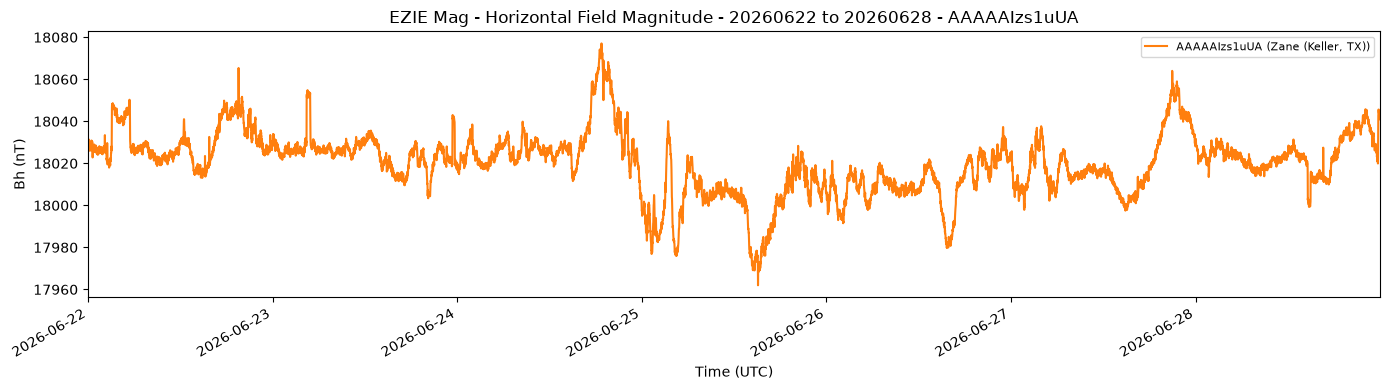

In [18]:
line_styles = ["-", "--", ":", "-."]

fig, ax = plt.subplots(figsize=(14, 4))

for i, (fp, df_device) in enumerate(dfs.items()):
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    label = f"{fp} ({name})"
    ls = line_styles[i % len(line_styles)]

    ax.plot(df_device.index, df_device["Bh"],
            color="tab:orange", linestyle=ls, label=label)

ax.set_ylabel("Bh (nT)")
ax.set_xlabel("Time (UTC)")

fp_str = " | ".join(FINGERPRINTS)
ax.set_title(
    f"EZIE Mag - Horizontal Field Magnitude - {date_label} - {fp_str}"
)

first_df = list(dfs.values())[0]
ax.set_xlim(first_df.index.min(), first_df.index.max())
ax.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 7. Declination (D)

$$D = \arctan2(B_y, B_x)$$

The angle, in degrees, of the horizontal field relative to the
sensor's +X axis across the full date range. Still relative to
the sensor's own axis until affine calibration is applied - not
yet true magnetic North. In multi-device mode, each device is
plotted on the same axes for direct comparison.

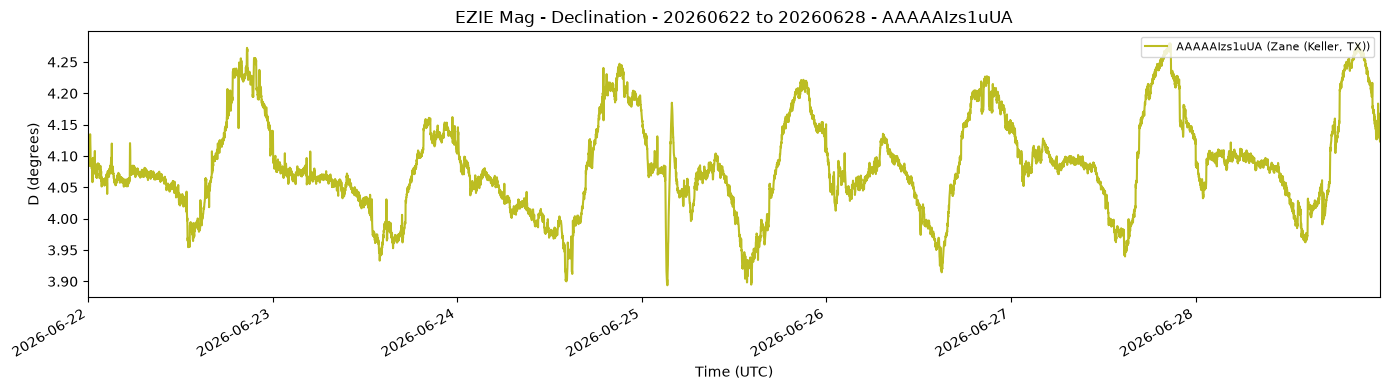

In [19]:
line_styles = ["-", "--", ":", "-."]

fig, ax = plt.subplots(figsize=(14, 4))

for i, (fp, df_device) in enumerate(dfs.items()):
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    label = f"{fp} ({name})"
    ls = line_styles[i % len(line_styles)]

    ax.plot(df_device.index, df_device["D"],
            color="tab:olive", linestyle=ls, label=label)

ax.set_ylabel("D (degrees)")
ax.set_xlabel("Time (UTC)")

fp_str = " | ".join(FINGERPRINTS)
ax.set_title(
    f"EZIE Mag - Declination - {date_label} - {fp_str}"
)

first_df = list(dfs.values())[0]
ax.set_xlim(first_df.index.min(), first_df.index.max())
ax.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 8. Comparison with USGS Observatories

Overlays EZIE data with public reference data from four USGS
geomagnetic observatories across the full date range:

| Code | Location | Distance from Arlington, TX |
|---|---|---|
| BSL | Stennis Space Center, MS | ~500 miles east (closest) |
| TUC | Tucson, AZ | ~900 miles west |
| BOU | Boulder, CO | ~900 miles north |
| FRD | Fredericksburg, VA | ~1,400 miles northeast |

Each dataset is **min-max normalized** before plotting:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

One figure is produced per observatory so each EZIE vs observatory
comparison is clean and readable, rather than overlaying all four
on the same axes. Each figure shows Bx/By/Bz (North/East/Down)
across the full date range.

**Known observation:** the East (By vs Y) component appears inverted
relative to the observatories due to the RM3100 sensor's internal
+Y axis pointing West rather than East. This will be corrected by
affine calibration.

Requires the `requests` library.

Fetching BSL...
  BSL 20260622: 1441 rows
  BSL 20260623: 1441 rows
  BSL 20260624: 1441 rows
  BSL 20260625: 1441 rows
  BSL 20260626: 1441 rows
  BSL 20260627: 1441 rows
  BSL 20260628: 1441 rows
  BSL total: 10081 rows
Fetching TUC...
  TUC 20260622: 1441 rows
  TUC 20260623: 1441 rows
  TUC 20260624: 1441 rows
  TUC 20260625: 1441 rows
  TUC 20260626: 1441 rows
  TUC 20260627: 1441 rows
  TUC 20260628: 1441 rows
  TUC total: 10081 rows
Fetching BOU...
  BOU 20260622: 1441 rows
  BOU 20260623: 1441 rows
  BOU 20260624: 1441 rows
  BOU 20260625: 1441 rows
  BOU 20260626: 1441 rows
  BOU 20260627: 1441 rows
  BOU 20260628: 1441 rows
  BOU total: 10081 rows
Fetching FRD...
  FRD 20260622: 1441 rows
  FRD 20260623: 1441 rows
  FRD 20260624: 1441 rows
  FRD 20260625: 1441 rows
  FRD 20260626: 1441 rows
  FRD 20260627: 1441 rows
  FRD 20260628: 1441 rows
  FRD total: 10081 rows


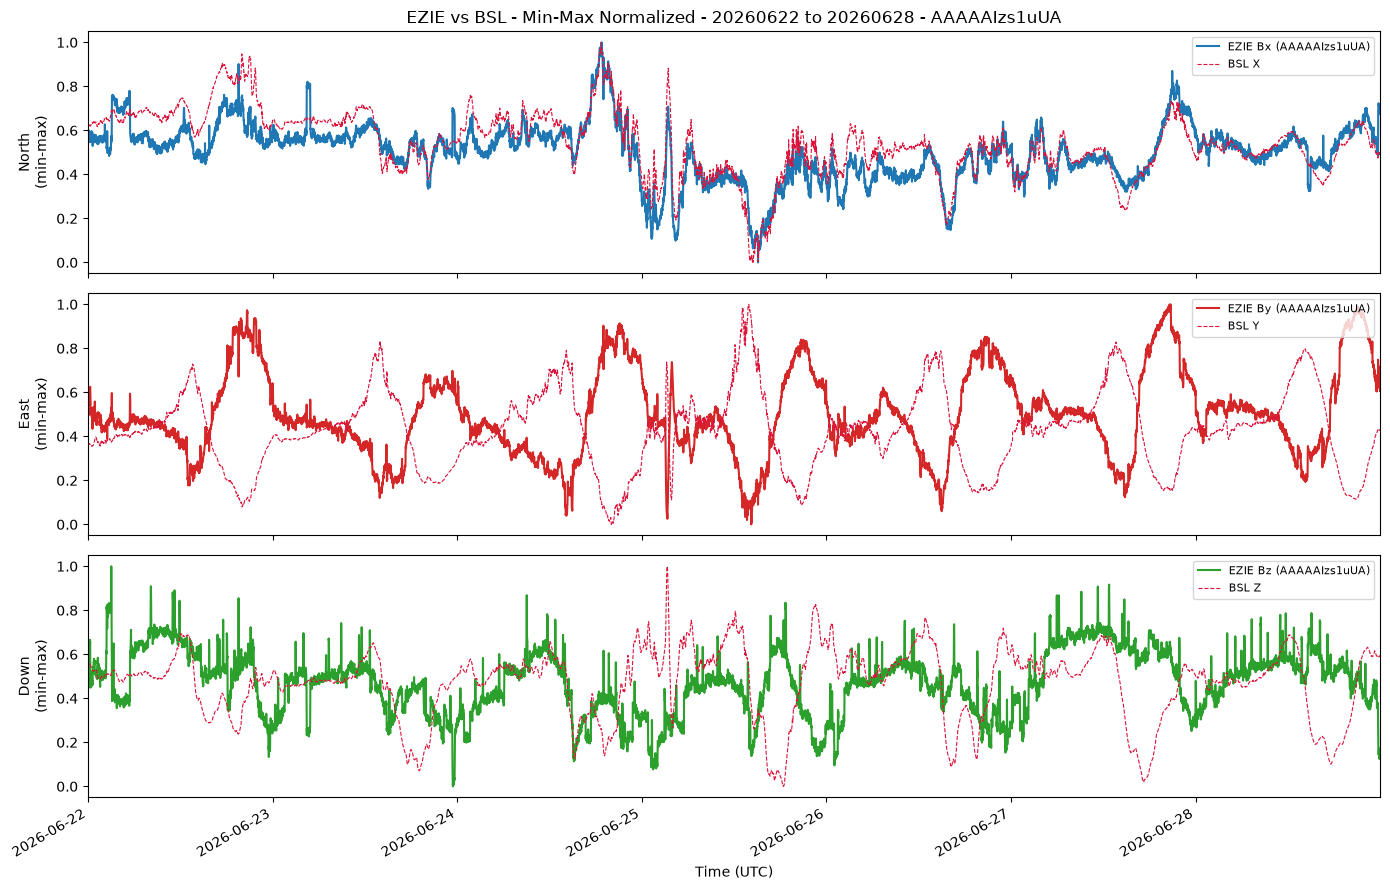

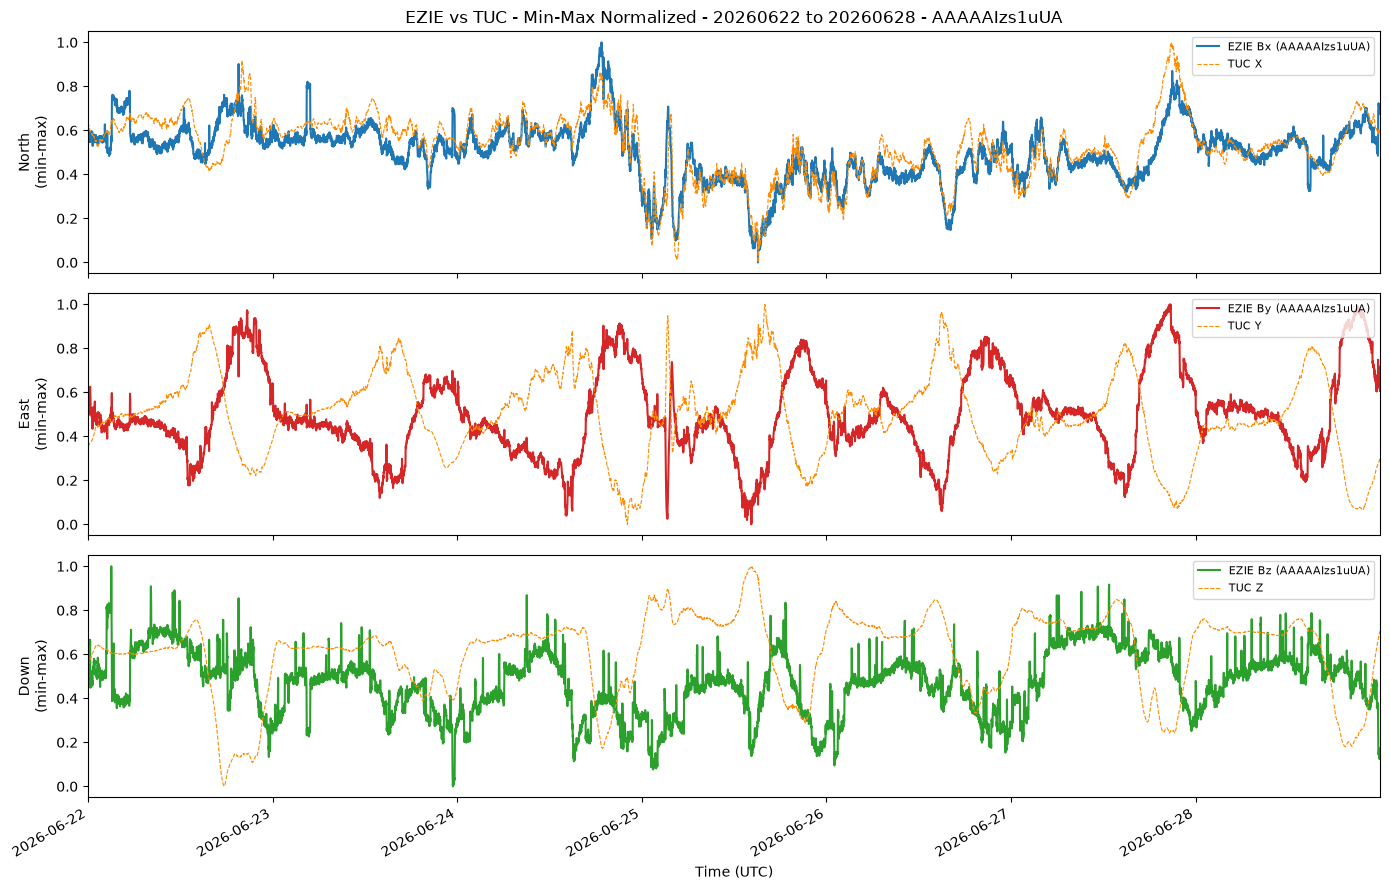

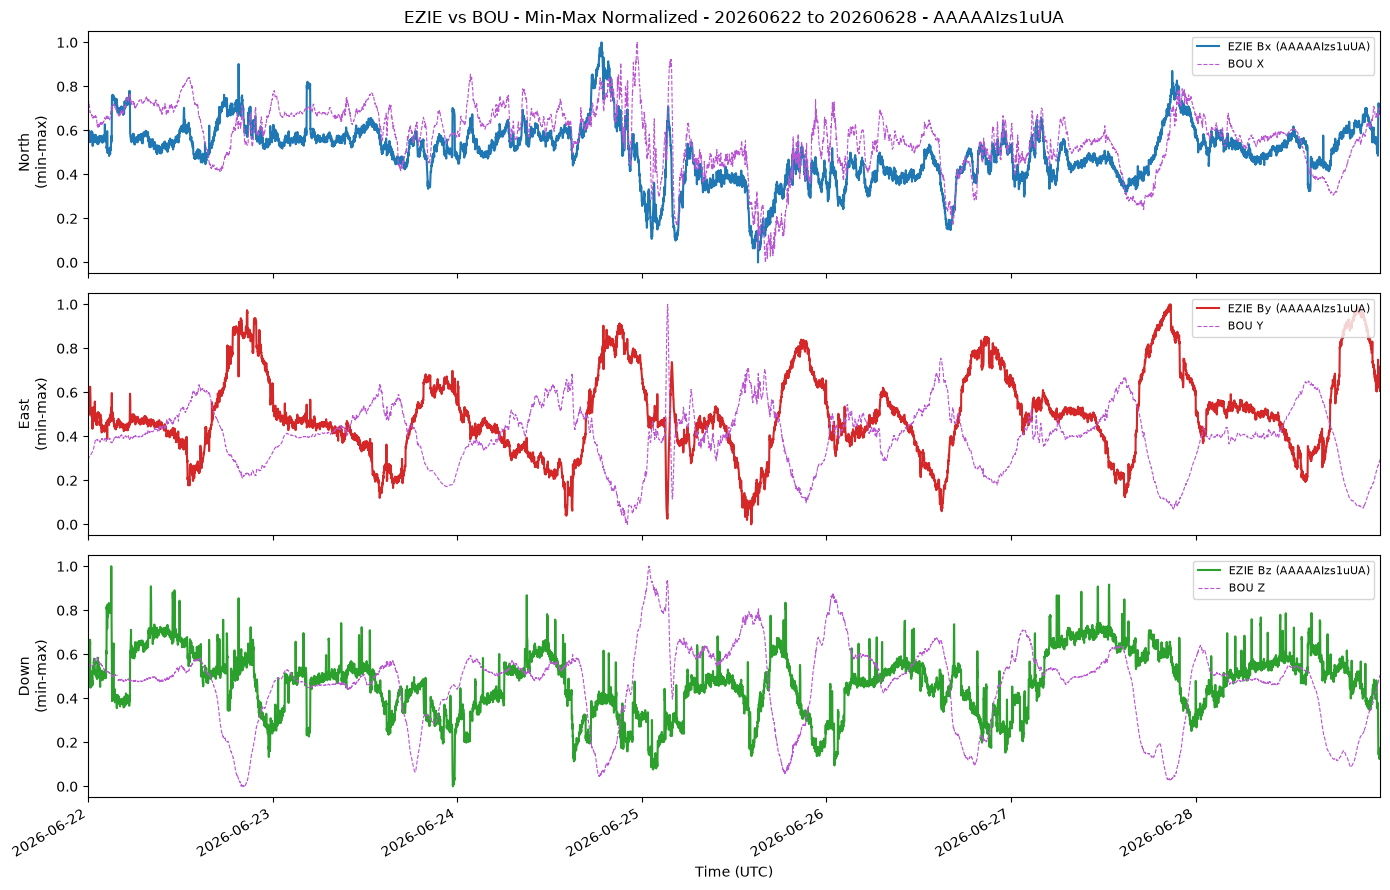

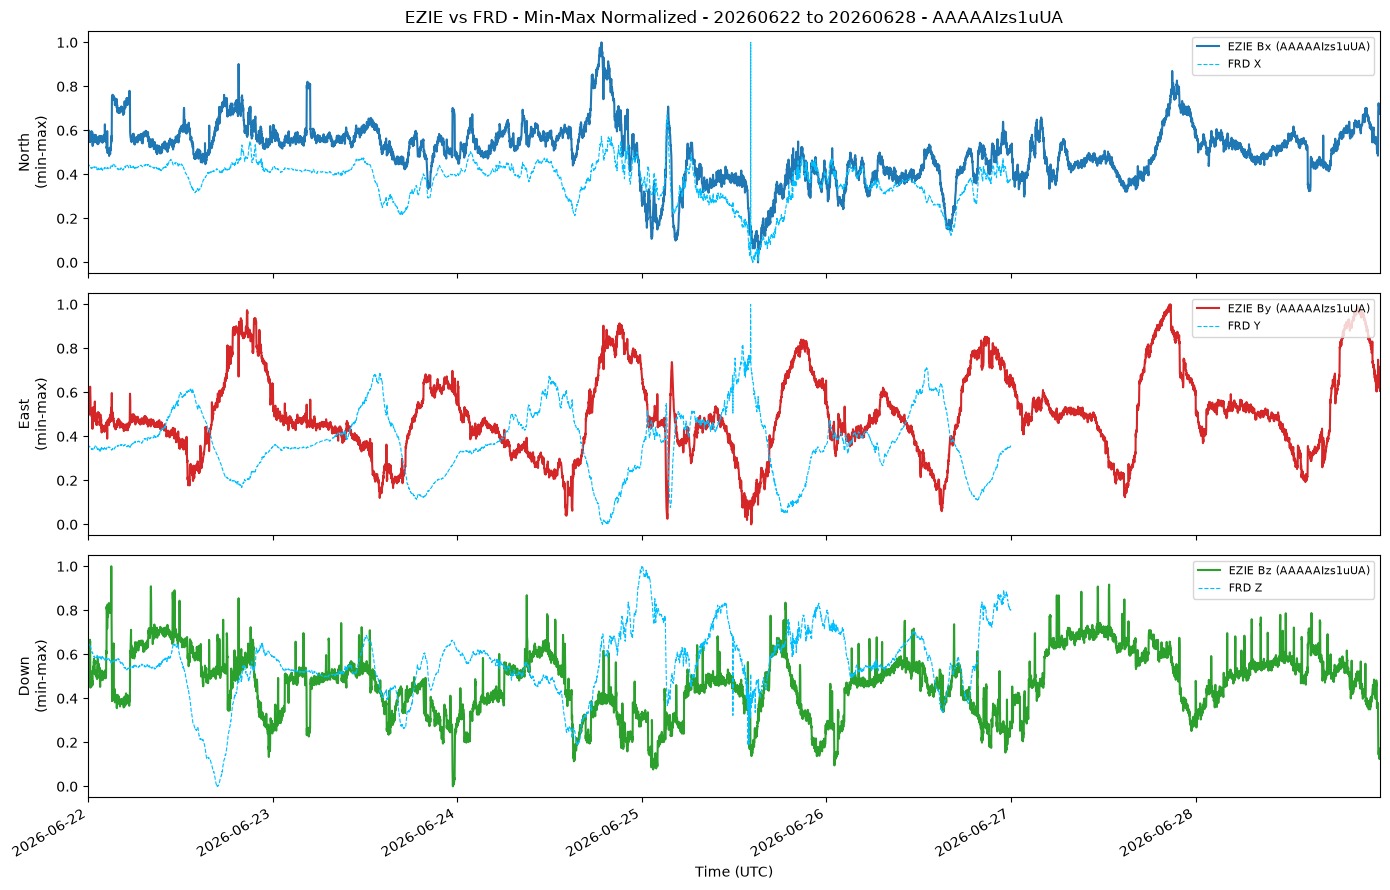

In [20]:
# --- Fetch reference data day-by-day to avoid API timeout ---
first_df = list(dfs.values())[0]

observatories = {
    "BSL": "crimson",       # Stennis, MS  - closest (~500 mi east)
    "TUC": "darkorange",    # Tucson, AZ   - (~900 mi west)
    "BOU": "mediumorchid",  # Boulder, CO  - (~900 mi north)
    "FRD": "deepskyblue",   # Fredericksburg, VA - (~1400 mi northeast)
}

obs_dfs = {}

for obs_id in observatories:
    print(f"Fetching {obs_id}...")
    daily_dfs = []

    for date_str in DATES:
        day_start = pd.Timestamp(date_str, tz="UTC")
        day_end = day_start + pd.Timedelta(days=1)

        url = (
            "https://geomag.usgs.gov/ws/data/"
            f"?id={obs_id}"
            f"&starttime={day_start.strftime('%Y-%m-%dT%H:%M:%SZ')}"
            f"&endtime={day_end.strftime('%Y-%m-%dT%H:%M:%SZ')}"
            f"&elements=X,Y,Z,F"
            f"&sampling_period=60"
            f"&format=json"
        )

        try:
            for attempt in range(3):
                try:
                    response = requests.get(url, timeout=60)
                    response.raise_for_status()
                    data = response.json()
                    break
                except Exception:
                    if attempt < 2:
                        print(f"  {obs_id} {date_str}: "
                              f"retrying ({attempt + 1}/3)...")
                    else:
                        raise

            times = pd.to_datetime(data["times"])
            day_df = pd.DataFrame(index=times)
            for element in data["values"]:
                name = element["metadata"]["element"]
                day_df[name] = element["values"]

            daily_dfs.append(day_df)
            print(f"  {obs_id} {date_str}: {day_df.shape[0]} rows")

        except Exception as e:
            print(f"  {obs_id} {date_str}: failed after 3 attempts ({e})")

    if daily_dfs:
        combined = pd.concat(daily_dfs).sort_index()
        combined = combined[~combined.index.duplicated(keep="first")]
        obs_dfs[obs_id] = combined
        print(f"  {obs_id} total: {obs_dfs[obs_id].shape[0]} rows")
    else:
        print(f"  {obs_id}: no data loaded")

# --- Helper function for min-max normalization ---
def minmax_norm(series):
    s_min = series.min()
    s_max = series.max()
    if s_max == s_min:
        return series * 0
    return (series - s_min) / (s_max - s_min)

# --- One figure per observatory ---
# Each figure shows EZIE Bx/By/Bz vs that observatory's X/Y/Z,
# min-max normalized, across the full date range.
components = [
    ("Bx", "X", "North", "tab:blue"),
    ("By", "Y", "East",  "tab:red"),
    ("Bz", "Z", "Down",  "tab:green")
]

line_styles = ["-", "--", ":", "-."]

fp_str = " | ".join(FINGERPRINTS)

for obs_id, obs_color in observatories.items():
    if obs_id not in obs_dfs:
        print(f"Skipping {obs_id} - no data loaded.")
        continue

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    for ax, (ezie_col, obs_col, label, ezie_color) in zip(axes, components):

        # Plot each EZIE device
        for i, (fp, df_device) in enumerate(dfs.items()):
            name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
            ls = line_styles[i % len(line_styles)]
            ezie_norm = minmax_norm(df_device[ezie_col])
            ax.plot(df_device.index, ezie_norm,
                    color=ezie_color, linestyle=ls, linewidth=1.5,
                    label=f"EZIE {ezie_col} ({fp})")

        # Plot this observatory
        if obs_col in obs_dfs[obs_id].columns:
            obs_norm = minmax_norm(obs_dfs[obs_id][obs_col])
            ax.plot(obs_dfs[obs_id].index, obs_norm,
                    color=obs_color, linestyle="--", linewidth=0.8,
                    label=f"{obs_id} {obs_col}")

        ax.set_ylabel(f"{label}\n(min-max)")
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlim(first_df.index.min(), first_df.index.max())
        ax.legend(loc="upper right", fontsize=8)

    axes[0].set_title(
        f"EZIE vs {obs_id} - Min-Max Normalized - "
        f"{date_label} - {fp_str}"
    )
    axes[-1].set_xlabel("Time (UTC)")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

## 9. Total Field and Horizontal Field - Observatory Comparison

Min-max normalized comparison of EZIE's derived fields against the
corresponding observatory quantities across the full date range,
one figure per observatory:

- **B_total** vs observatory **F** (total field magnitude)
- **Bh** vs observatory **H** (horizontal field magnitude)

Bh is the primary scientific comparison metric since Bz varies
significantly between stations due to local conditions. One figure
per observatory keeps each comparison clean and readable over a
multi-day range.

Requires the `requests` library.

Fetching H, F for BSL...
  BSL 20260622: 1441 rows
  BSL 20260623: 1441 rows
  BSL 20260624: 1441 rows
  BSL 20260625: 1441 rows
  BSL 20260626: 1441 rows
  BSL 20260627: 1441 rows
  BSL 20260628: 1441 rows
  BSL total: 10081 rows
Fetching H, F for TUC...
  TUC 20260622: 1441 rows
  TUC 20260623: 1441 rows
  TUC 20260624: 1441 rows
  TUC 20260625: 1441 rows
  TUC 20260626: 1441 rows
  TUC 20260627: 1441 rows
  TUC 20260628: 1441 rows
  TUC total: 10081 rows
Fetching H, F for BOU...
  BOU 20260622: 1441 rows
  BOU 20260623: 1441 rows
  BOU 20260624: 1441 rows
  BOU 20260625: 1441 rows
  BOU 20260626: 1441 rows
  BOU 20260627: 1441 rows
  BOU 20260628: 1441 rows
  BOU total: 10081 rows
Fetching H, F for FRD...
  FRD 20260622: 1441 rows
  FRD 20260623: 1441 rows
  FRD 20260624: 1441 rows
  FRD 20260625: 1441 rows
  FRD 20260626: 1441 rows
  FRD 20260627: 1441 rows
  FRD 20260628: 1441 rows
  FRD total: 10081 rows


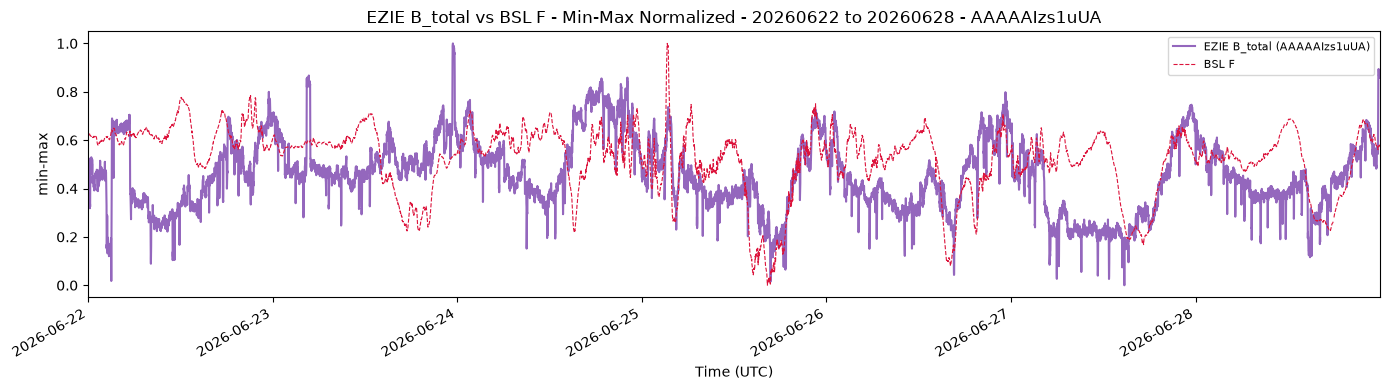

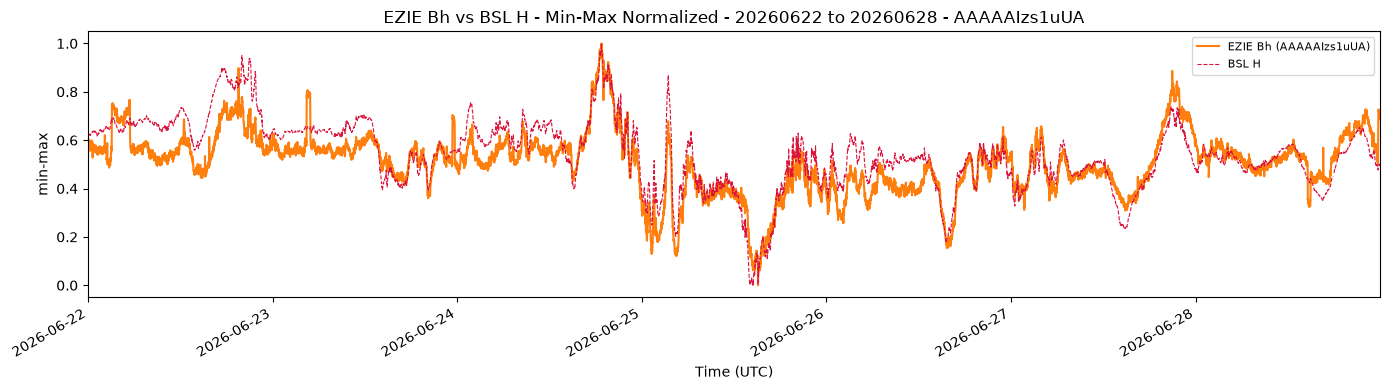

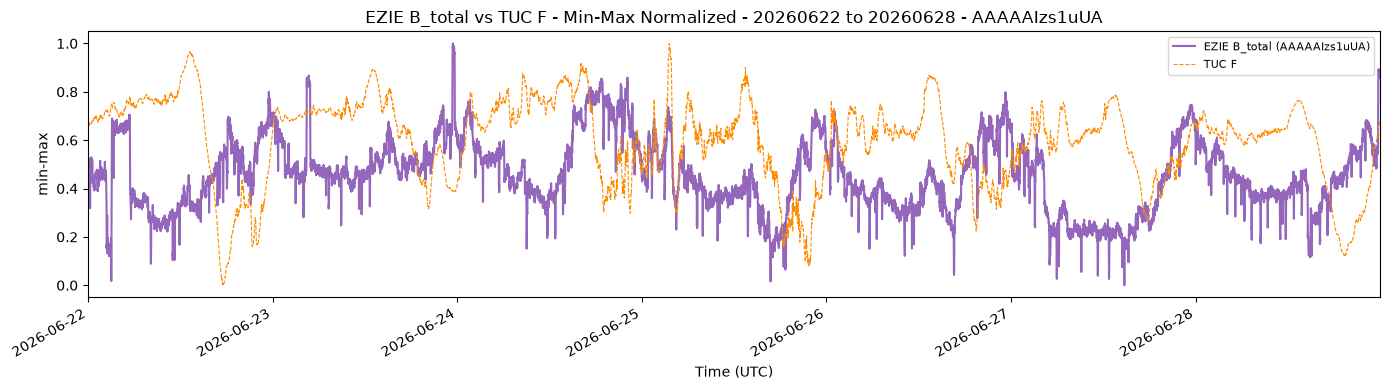

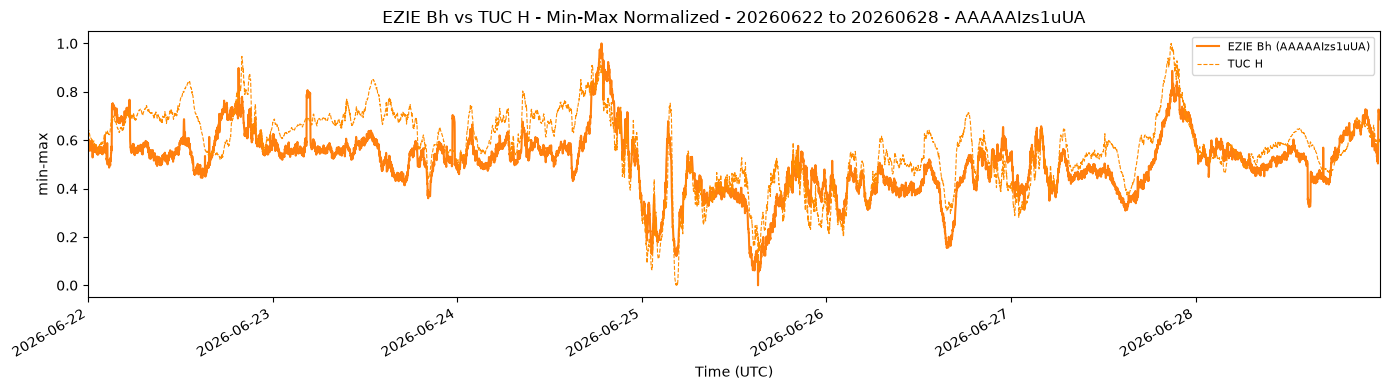

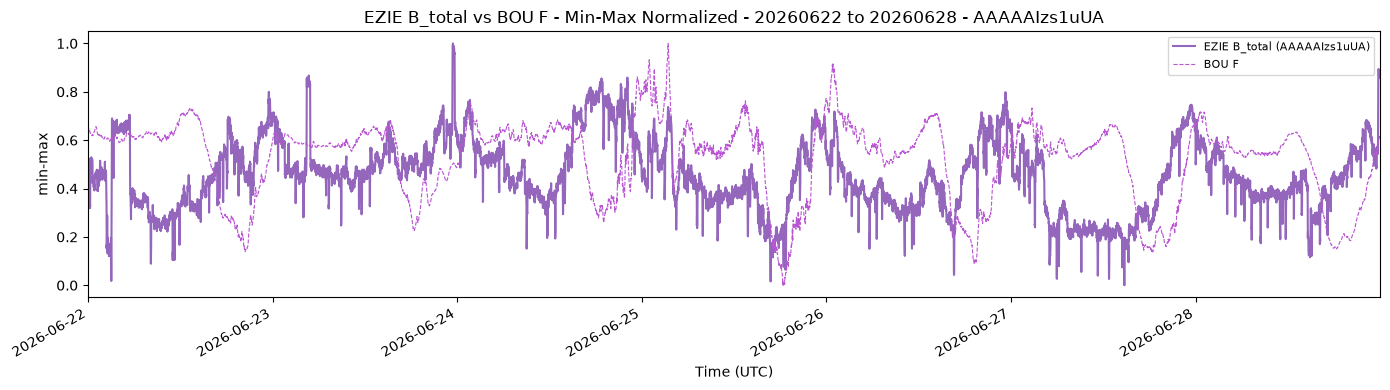

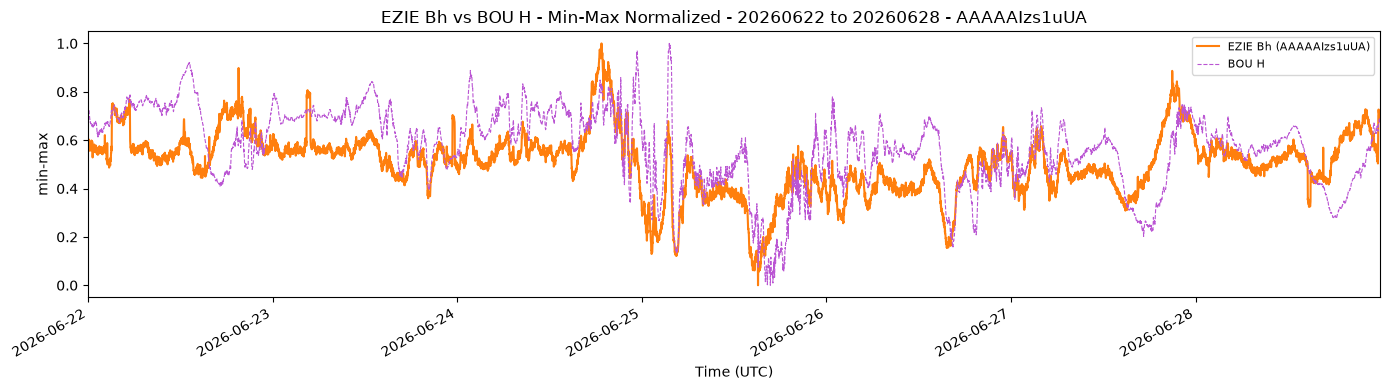

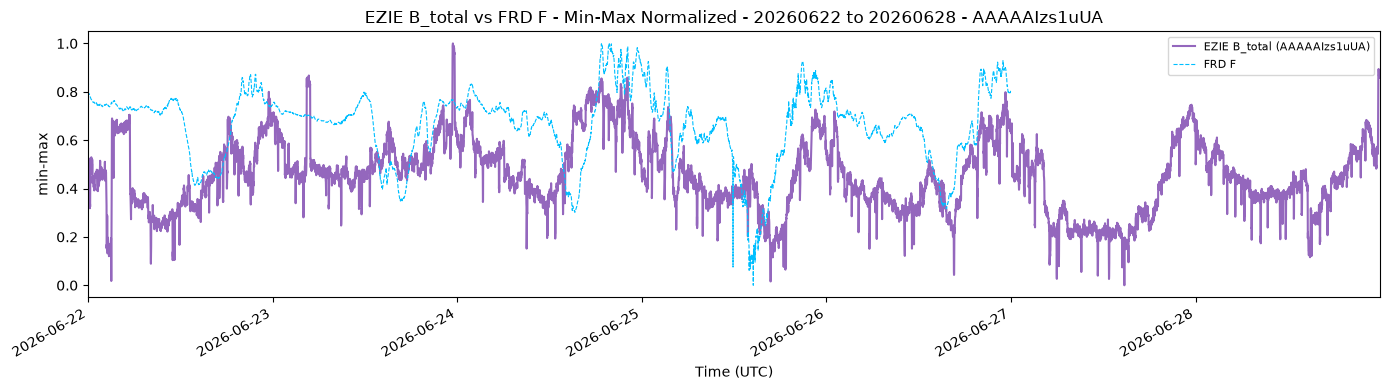

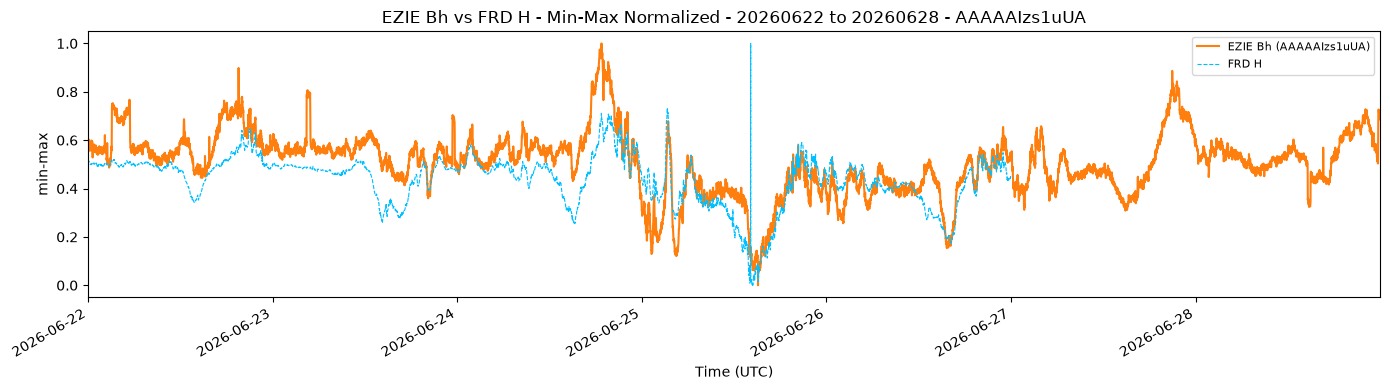

In [11]:
# --- Fetch H and F day-by-day from all four observatories ---
obs_dfs_hf = {}

for obs_id in observatories:
    print(f"Fetching H, F for {obs_id}...")
    daily_dfs = []

    for date_str in DATES:
        day_start = pd.Timestamp(date_str, tz="UTC")
        day_end = day_start + pd.Timedelta(days=1)

        url = (
            "https://geomag.usgs.gov/ws/data/"
            f"?id={obs_id}"
            f"&starttime={day_start.strftime('%Y-%m-%dT%H:%M:%SZ')}"
            f"&endtime={day_end.strftime('%Y-%m-%dT%H:%M:%SZ')}"
            f"&elements=H,F"
            f"&sampling_period=60"
            f"&format=json"
        )

        try:
            for attempt in range(3):
                try:
                    response = requests.get(url, timeout=60)
                    response.raise_for_status()
                    data = response.json()
                    break
                except Exception:
                    if attempt < 2:
                        print(f"  {obs_id} {date_str}: "
                              f"retrying ({attempt + 1}/3)...")
                    else:
                        raise

            times = pd.to_datetime(data["times"])
            day_df = pd.DataFrame(index=times)
            for element in data["values"]:
                name = element["metadata"]["element"]
                day_df[name] = element["values"]

            daily_dfs.append(day_df)
            print(f"  {obs_id} {date_str}: {day_df.shape[0]} rows")

        except Exception as e:
            print(f"  {obs_id} {date_str}: failed after 3 attempts ({e})")

    if daily_dfs:
        combined = pd.concat(daily_dfs).sort_index()
        combined = combined[~combined.index.duplicated(keep="first")]
        obs_dfs_hf[obs_id] = combined
        print(f"  {obs_id} total: {obs_dfs_hf[obs_id].shape[0]} rows")
    else:
        print(f"  {obs_id}: no data loaded")

# --- One figure per observatory per derived field ---
# Produces 8 figures total: 4 observatories x 2 fields (B_total, Bh)
# Each figure is a clean standalone comparison suitable for
# presentation or export as a PNG.
for obs_id, obs_color in observatories.items():
    if obs_id not in obs_dfs_hf:
        print(f"Skipping {obs_id} - no data loaded.")
        continue

    # --- B_total vs F ---
    fig, ax = plt.subplots(figsize=(14, 4))

    for i, (fp, df_device) in enumerate(dfs.items()):
        name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
        ls = line_styles[i % len(line_styles)]
        ezie_norm = minmax_norm(df_device["B_total"])
        ax.plot(df_device.index, ezie_norm,
                color="tab:purple", linestyle=ls, linewidth=1.5,
                label=f"EZIE B_total ({fp})")

    if "F" in obs_dfs_hf[obs_id].columns:
        obs_norm = minmax_norm(obs_dfs_hf[obs_id]["F"])
        ax.plot(obs_dfs_hf[obs_id].index, obs_norm,
                color=obs_color, linestyle="--", linewidth=0.8,
                label=f"{obs_id} F")

    ax.set_ylabel("min-max")
    ax.set_xlabel("Time (UTC)")
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(first_df.index.min(), first_df.index.max())
    ax.set_title(
        f"EZIE B_total vs {obs_id} F - "
        f"Min-Max Normalized - {date_label} - {fp_str}"
    )
    ax.legend(loc="upper right", fontsize=8)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    # --- Bh vs H ---
    fig, ax = plt.subplots(figsize=(14, 4))

    for i, (fp, df_device) in enumerate(dfs.items()):
        name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
        ls = line_styles[i % len(line_styles)]
        ezie_norm = minmax_norm(df_device["Bh"])
        ax.plot(df_device.index, ezie_norm,
                color="tab:orange", linestyle=ls, linewidth=1.5,
                label=f"EZIE Bh ({fp})")

    if "H" in obs_dfs_hf[obs_id].columns:
        obs_norm = minmax_norm(obs_dfs_hf[obs_id]["H"])
        ax.plot(obs_dfs_hf[obs_id].index, obs_norm,
                color=obs_color, linestyle="--", linewidth=0.8,
                label=f"{obs_id} H")

    ax.set_ylabel("min-max")
    ax.set_xlabel("Time (UTC)")
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(first_df.index.min(), first_df.index.max())
    ax.set_title(
        f"EZIE Bh vs {obs_id} H - "
        f"Min-Max Normalized - {date_label} - {fp_str}"
    )
    ax.legend(loc="upper right", fontsize=8)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

## 10. Summary Statistics

Overview of the magnetic field data across the full date range
per device - useful for reports and spotting day-to-day trends
or anomalies. Flag column counts are included so any quality
issues identified during processing are immediately visible
alongside the measurements.

In [12]:
for fp, df_device in dfs.items():
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")

    print(f"\n{'='*60}")
    print(f"Summary Statistics: {date_label}")
    print(f"Device: {fp} ({name})")
    print(f"{'='*60}")

    # --- Shape and coverage ---
    days_loaded = df_device.index.normalize().nunique()
    print(f"Days loaded:  {days_loaded} / {len(DATES)} requested")
    print(f"Total rows:   {len(df_device)}")
    print(f"Missing mins: {df_device['flag_missing'].sum()}")

    # --- Measurement statistics ---
    display(df_device[["Bx", "By", "Bz", "B_total", "Bh", "D"]].describe())

    # --- Flag summary across all loaded days ---
    print("\nFlag Summary (across all days):")
    flag_cols = [c for c in df_device.columns if c.startswith("flag_")]
    flagged = {
        c: int(df_device[c].sum())
        for c in flag_cols
        if df_device[c].sum() > 0
    }

    if flagged:
        for flag, count in flagged.items():
            print(f"  {flag}: {count} row(s)")
    else:
        print("  No flags raised across the date range.")


Summary Statistics: 20260622 to 20260628
Device: AAAAAIzs1uUA (Zane (Keller, TX))
Days loaded:  7 / 7 requested
Total rows:   10080
Missing mins: 5


,Bx,By,Bz,B_total,Bh,D
count,10075.000000,10075.000000,10075.000000,10075.000000,10075.000000,10075.000000
mean,17974.454074,1283.659901,-35567.565405,39872.061356,18020.248511,4.084863
std,14.296042,24.351681,11.379150,11.869464,14.931281,0.076198
min,17919.656241,1221.107665,-35604.708994,39836.206494,17961.982886,3.893804
25%,17966.098095,1268.886248,-35575.235964,39864.087108,18011.874531,4.039377
50%,17976.013476,1280.811014,-35566.447368,39871.582914,18021.764349,4.076505
75%,17982.410310,1297.888848,-35560.080788,39879.888587,18027.834560,4.130020
max,18028.892232,1346.885645,-35525.644344,39914.841064,18077.054179,4.279611



Flag Summary (across all days):
  flag_outlier_bx: 90 row(s)
  flag_outlier_bz: 41 row(s)
  flag_outlier_bh: 57 row(s)
  flag_low_nsamp: 97 row(s)
  flag_sensor_disturbed: 192 row(s)
  flag_missing: 5 row(s)
